# MCDI505 — Análisis de Series de Tiempo
## Sumativa 1 — Informe de análisis exploratorio de la serie de consumo eléctrico comercial

| | |
|---|---|
| **Estudiante** | Claudio Rodolfo Alarcón Pradenas — Magíster en Ciencia de Datos e Inteligencia Artificial, Universidad Andrés Bello |
| **Docente** | Dr. Harvey Jezlid Rosas Quintero |
| **Evaluación** | Sumativa 1 · Semana 1 · Fase 1 (definición y orientación de la situación) · 4 de octubre de 2026 |
| **Datos** | `consumo_electrico_litoral.csv` (caso transversal del curso) |
| **Repositorio (respaldo y reproducibilidad)** | `https://github.com/claudioalarconP/Analisis_de_serie_de_tiempo` |

## 1. Introducción y objetivo

**Contexto.** La Distribuidora Eléctrica del Litoral (DEL) abastece a comunas de la Región de Valparaíso; su segmento comercial concentra cerca de un tercio de la energía distribuida y es el más estacional. Cada diciembre, DEL compromete los volúmenes mensuales del año siguiente: contratar de menos obliga a comprar en el mercado *spot* a precios entre 2 y 4 veces mayores, y contratar de más, a pagar energía no consumida (Universidad Andrés Bello [UNAB], s. f.-a).

**Datos.** Variable objetivo: `consumo_gwh` (energía mensual facturada al segmento comercial, GWh); covariables: `clientes_comerciales`, `temperatura_media_c` y `dias_habiles`. Son datos sintéticos, tratados como un caso observado sin conocer su proceso generador.

**Partición.** El dataset completo contiene 120 observaciones mensuales entre enero de 2015 y diciembre de 2024. Conforme al protocolo del caso transversal, el análisis de la Semana 1 se realiza exclusivamente sobre las **108 observaciones de enero de 2015 a diciembre de 2023**. Las 12 observaciones de 2024 se mantienen selladas para la evaluación final del modelo en la Semana 4 (UNAB, s. f.-a); sobre las 120 filas solo se verifica la integridad estructural del archivo.

**Objetivo.** Identificar tendencia, estacionalidad, ciclo y error, relacionarlos con la ACF y la PACF, y derivar implicancias para el modelamiento posterior.

## 2. Configuración y reproducibilidad

Se usan `pandas`, `numpy`, `matplotlib` y `statsmodels` (Seabold y Perktold, 2010). El CSV se busca con rutas relativas (junto al notebook, en `data/raw/` desde la raíz del repositorio o en `../../../data/raw/` desde su carpeta; en Google Colab se pide subirlo) y no se modifica: toda limpieza ocurre en memoria.

In [1]:
# --- Bibliotecas ---
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
np.random.seed(505)          # semilla del curso (no hay procesos aleatorios en este análisis)
# --- Estilo común de los gráficos (paleta del material docente) ---
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3, "font.size": 9,
                     "axes.titlesize": 10, "axes.spines.top": False, "axes.spines.right": False})
ROJO, AZUL, GRIS = "#b30338", "#0057b8", "#9e9e9e"
print(f"Python {sys.version.split()[0]} | pandas {pd.__version__} | statsmodels {statsmodels.__version__}")

Python 3.12.5 | pandas 3.0.3 | statsmodels 0.14.6


## 3. Carga y auditoría del dataset

In [2]:
# --- Búsqueda del CSV con rutas relativas (junto al notebook o en la estructura del proyecto) ---
ARCHIVO = "consumo_electrico_litoral.csv"
rutas = [Path(ARCHIVO), Path("data/raw") / ARCHIVO,
         Path("../../../data/raw") / ARCHIVO, Path("../../data/raw") / ARCHIVO,
         Path("../data/raw") / ARCHIVO]
ruta = next((r for r in rutas if r.exists()), None)
if ruta is None:                           # no está en disco: en Colab se sube manualmente
    try:
        from google.colab import files
        files.upload()
        ruta = Path(ARCHIVO)
    except ImportError:                    # no es Colab: se informa el error abajo
        pass
if ruta is None or not ruta.exists():
    raise FileNotFoundError(f"No se encontró '{ARCHIVO}': ubíquelo junto al notebook, "
                            "en data/raw/ (raíz del proyecto), en ../../../data/raw/ o súbalo en Google Colab.")
df = pd.read_csv(ruta, parse_dates=["fecha"]).set_index("fecha").asfreq("MS")  # índice mensual
print("Archivo:", ruta)
# --- Auditoría de la estructura temporal (las 120 filas del archivo) ---
idx, y_obs = df.index, df["consumo_gwh"]
calendario = pd.date_range(idx.min(), idx.max(), freq="MS")   # calendario mensual esperado
print(f"Filas: {len(df)} | {idx.min():%Y-%m} a {idx.max():%Y-%m} | frecuencia: {idx.freqstr} | "
      f"orden cronológico: {idx.is_monotonic_increasing} | fechas duplicadas: {idx.duplicated().sum()} | "
      f"meses ausentes: {len(calendario.difference(idx))}")
print(f"consumo_gwh sin dato: {list(y_obs[y_obs.isna()].index.strftime('%Y-%m'))} | "
      f"valores no positivos: {(y_obs <= 0).sum()} | "
      f"nulos en covariables: {df.drop(columns='consumo_gwh').isna().sum().sum()}")
# --- Partición del caso: 2024 queda sellado como conjunto de prueba (Semana 4) ---
train = df.loc[:"2023-12-01"].copy()          # único objeto usado desde aquí en adelante
assert len(train) == 108 and train.index.max() == pd.Timestamp("2023-12-01")
assert not train.index.year.isin([2024]).any(), "2024 debe permanecer sellado"
print(f"Periodo analizado: {train.index.min():%Y-%m} a {train.index.max():%Y-%m} "
      f"({len(train)} meses). Periodo sellado: 2024 ({len(df) - len(train)} meses).")

Archivo: ..\..\data\raw\consumo_electrico_litoral.csv
Filas: 120 | 2015-01 a 2024-12 | frecuencia: MS | orden cronológico: True | fechas duplicadas: 0 | meses ausentes: 0
consumo_gwh sin dato: ['2016-08', '2019-02', '2022-06'] | valores no positivos: 0 | nulos en covariables: 0
Periodo analizado: 2015-01 a 2023-12 (108 meses). Periodo sellado: 2024 (12 meses).


El índice es mensual (`MS`), ordenado y sin duplicados ni meses ausentes. Solo `consumo_gwh` tiene faltantes: 2016-08, 2019-02 y 2022-06, todos dentro del periodo de análisis. Un mes sin registro no equivale a consumo cero, por lo que se imputa (sección 4). Desde aquí todo el análisis usa `train` (108 meses).

## 4. Tratamiento mínimo de faltantes y anomalías

### 4.1 Valores faltantes

Los huecos no son equivalentes: agosto de 2016 cae en la meseta invernal, febrero de 2019 en el descenso tras el máximo de enero y junio de 2022 en el ascenso al máximo invernal. Las tres estrategias del caso se validan borrando artificialmente meses conocidos del mismo mes calendario.

In [3]:
# --- Comparación de estrategias de imputación para los tres huecos ---
s = train["consumo_gwh"]
huecos = s[s.isna()].index
def imputar(x):
    """Las tres estrategias del notebook del caso, aplicadas a la serie x."""
    return {"lineal": x.interpolate("linear"),
            "temporal": x.interpolate("time"),
            "estacional ajustada": x.fillna(x.shift(12) * (x.shift(1) / x.shift(13)))}
# (a) Vecinos observados y valor que propone cada estrategia
tabla = pd.DataFrame({"mes anterior": s.shift(1)[huecos], "mes siguiente": s.shift(-1)[huecos]})
for k, v in imputar(s).items():
    tabla[k] = v[huecos]
# (b) Huecos simulados: se borra cada valor conocido del MISMO mes calendario y se mide el
#     error absoluto medio (EAM) de cada estrategia. Se excluyen 2015 (sin año previo),
#     el periodo COVID y noviembre de 2017 (atípico).
excluir = pd.date_range("2020-03-01", "2021-12-01", freq="MS").append(
    pd.DatetimeIndex(["2017-11-01"]))
for h in huecos:
    meses = s.index[(s.index.month == h.month) & s.notna() & (s.index.year > 2015)
                    & ~s.index.isin(excluir)]
    err = {k: [] for k in imputar(s)}
    for d in meses:
        x = s.copy()
        x[d] = np.nan                                    # hueco simulado
        for k, v in imputar(x).items():
            if pd.notna(v[d]):
                err[k].append(abs(v[d] - s[d]))
    tabla.loc[h, "n validación"] = len(meses)
    for k, e in err.items():
        tabla.loc[h, f"EAM {k}"] = np.mean(e)
display(tabla.round(2))                                  # valores imputados (GWh) y EAM (GWh)

,mes anterior,mes siguiente,lineal,temporal,estacional ajustada,n validación,EAM lineal,EAM temporal,EAM estacional ajustada
fecha,,,,,,,,,
2016-08-01,98.28,93.44,95.86,95.86,94.87,5.0,2.84,2.84,4.13
2019-02-01,128.36,105.49,116.93,116.34,114.18,6.0,3.60,3.53,7.20
2022-06-01,99.24,103.55,101.40,101.43,103.86,5.0,1.17,1.12,3.31


| Elemento | Decisión 4.1 — Imputación |
|---|---|
| **Decisión** | Interpolación lineal en los tres huecos: 95,86 (2016-08), 116,93 (2019-02) y 101,40 GWh (2022-06). |
| **Evidencia** | En la validación, la lineal y la temporal tienen errores prácticamente iguales (EAM 2,84/2,84; 3,60/3,53; 1,17/1,12 GWh), muy inferiores a la estacional (4,13; 7,20; 3,31 GWh), que arrastra el ruido del año anterior. |
| **Alternativa descartada** | Interpolación temporal: no mejora materialmente el error y la serie tiene frecuencia mensual regular. |
| **Consecuencia** | Febrero de 2019 es el hueco más incierto (≈ 3,6 GWh); la imputación afecta solo 3 de 108 meses (2,8 %) y puede inflar levemente la ACF(1). |

### 4.2 Atípico de noviembre de 2017

El área de operaciones informó una recalibración de medidores en noviembre de 2017 (UNAB, s. f.-a). Se verifica con el procedimiento del notebook del caso: *z* robusto (mediana y MAD) del componente irregular.

In [4]:
# --- z robusto del componente irregular (procedimiento del notebook del caso) ---
s_lin = s.interpolate("linear")                        # serie provisional sin huecos
nivel = s_lin.rolling(12, center=True).mean().rolling(2, center=True).mean().shift(-1)
razon = (s_lin / nivel).dropna()                       # estacionalidad + irregular
irregular = razon / razon.groupby(razon.index.month).transform("median")  # sin efecto mes
mad = (irregular - irregular.median()).abs().median()
z = (irregular - irregular.median()) / (1.4826 * mad)
print("Meses con |z| > 3,5:", {f"{d:%Y-%m}": round(v, 2) for d, v in z[z.abs() > 3.5].items()})
# Evidencia específica de noviembre de 2017
yoy = 100 * (s_lin / s_lin.shift(12) - 1)
resto = yoy.drop(excluir).dropna()                     # sin COVID ni 2017-11
nov_dic = {a: round(float(s_lin[f"{a}-11-01"] / s_lin[f"{a}-12-01"]), 3) for a in range(2015, 2024)}
print(f"Var. interanual 2017-11: {yoy['2017-11-01']:+.1f} % (resto: media {resto.mean():.1f} %, "
      f"desv. est. {resto.std():.1f}, máximo {resto.max():.1f} %)")
print("Razón noviembre/diciembre por año:", nov_dic)
# --- Serie de trabajo: el atípico se trata como faltante y se imputa como los huecos ---
y = s.copy()
y["2017-11-01"] = np.nan                  # recalibración de medidores: no es consumo real
y = y.interpolate("linear")               # decisión de la sección 4.1
a1, b1 = acf(s_lin, nlags=12)[[1, 12]], acf(y, nlags=12)[[1, 12]]
print(f"2017-11: {s['2017-11-01']:.2f} → {y['2017-11-01']:.2f} GWh | media {s_lin.mean():.2f} → "
      f"{y.mean():.2f} GWh | desv. est. {s_lin.std():.3f} → {y.std():.3f} GWh | "
      f"ACF(1) {a1[0]:.3f} → {b1[0]:.3f} | ACF(12) {a1[1]:.3f} → {b1[1]:.3f}")

Meses con |z| > 3,5: {'2017-11': 4.05, '2019-10': 3.51, '2020-02': 3.64, '2020-04': -5.2, '2020-05': -7.46, '2020-06': -5.19}
Var. interanual 2017-11: +13.8 % (resto: media 4.5 %, desv. est. 4.4, máximo 13.5 %)
Razón noviembre/diciembre por año: {2015: 0.857, 2016: 0.885, 2017: 0.992, 2018: 0.958, 2019: 0.889, 2020: 0.839, 2021: 0.874, 2022: 0.911, 2023: 0.894}
2017-11: 118.96 → 107.85 GWh | media 102.90 → 102.80 GWh | desv. est. 12.583 → 12.495 GWh | ACF(1) 0.745 → 0.748 | ACF(12) 0.652 → 0.650


Noviembre de 2017 es el único candidato con |*z*| > 3,5 fuera del COVID (*z* = 4,05); 2019-10 y 2020-02 lo superan solo porque su media móvil incluye la caída de 2020. La prueba más clara es la razón noviembre/diciembre: 0,992, frente a 0,839–0,958 en los demás años.

| Elemento | Decisión 4.2 — Atípico |
|---|---|
| **Decisión** | Tratarlo como faltante e interpolarlo (118,96 → 107,85 GWh); el original se conserva en `df`. |
| **Evidencia** | *z* = 4,05, razón noviembre/diciembre fuera de rango y causa documentada (recalibración, no consumo real). |
| **Alternativa descartada** | Conservarlo: distorsionaría el factor estacional de noviembre, la descomposición y la ACF. |
| **Consecuencia** | Efecto global pequeño (media 102,90 → 102,80 GWh; ACF(1) 0,745 → 0,748); el relevante es local, en noviembre. La Figura 1 muestra solo el valor imputado. |

## 5. Exploración y visualización

### 5.1 Serie temporal, cambios de nivel y shock COVID-19

La variación interanual (Figura 1, abajo) compara cada mes con el mismo mes del año anterior; así elimina la estacionalidad y deja ver los cambios de nivel.

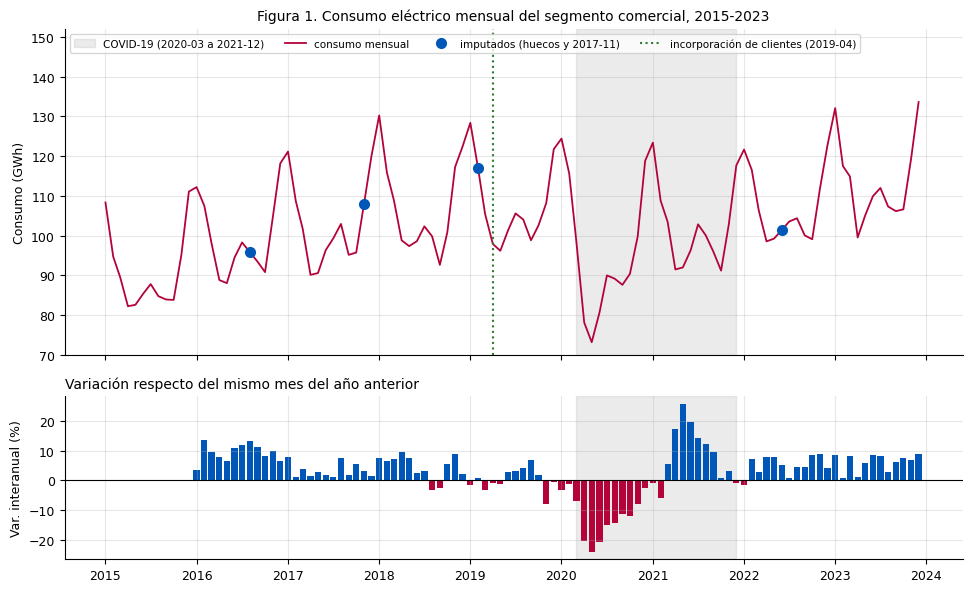

Mayor caída interanual: 2020-05 (-23.9 %); 2020-03 a 2020-06: [-6.9, -20.2, -23.9, -20.4]
Var. interanual 2021-04 a 2021-07 (efecto base): [17.1, 25.7, 19.5, 14.3]
Nivel vs. mismo mes de 2019 → 2021: -11.1 % a -1.9 %; 2022: -5.2 % a +3.4 %
Clientes: alza 2019-03 → 2019-04 = +1059 (mediana mensual 120)


In [5]:
# --- Figura 1: serie mensual, eventos del periodo y variación interanual ---
covid = (pd.Timestamp("2020-03-01"), pd.Timestamp("2021-12-01"))
nov17 = pd.Timestamp("2017-11-01")
var_ia = 100 * (y / y.shift(12) - 1)          # vs. el mismo mes del año anterior
imputados = huecos.append(pd.DatetimeIndex([nov17]))
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
ax = axes[0]
ax.axvspan(*covid, color=GRIS, alpha=0.2, label="COVID-19 (2020-03 a 2021-12)")
ax.plot(y.index, y, color=ROJO, lw=1.3, label="consumo mensual")
ax.plot(imputados, y[imputados], "o", color=AZUL, ms=7, label="imputados (huecos y 2017-11)")
ax.axvline(pd.Timestamp("2019-04-01"), color="#2e7d32", ls=":", lw=1.5,
           label="incorporación de clientes (2019-04)")
ax.set(ylim=(70, 152), ylabel="Consumo (GWh)",              # ylim: espacio para la leyenda
       title="Figura 1. Consumo eléctrico mensual del segmento comercial, 2015-2023")
ax.legend(fontsize=7.5, ncol=4, loc="upper left")   # una sola fila
axes[1].axvspan(*covid, color=GRIS, alpha=0.2)
axes[1].bar(var_ia.index, var_ia, width=25, color=np.where(var_ia < 0, ROJO, AZUL))
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_ylabel("Var. interanual (%)")
axes[1].set_title("Variación respecto del mismo mes del año anterior", loc="left")
plt.tight_layout()
plt.show()
# --- Cifras que delimitan el shock y los cambios de nivel ---
vs19 = pd.Series({d: 100 * (y[d] / y[f"2019-{d.month:02d}-01"] - 1) for d in y["2021":"2022"].index})
dc = train["clientes_comerciales"].diff()
print(f"Mayor caída interanual: {var_ia.idxmin():%Y-%m} ({var_ia.min():+.1f} %); "
      f"2020-03 a 2020-06: {var_ia['2020-03':'2020-06'].round(1).tolist()}")
print("Var. interanual 2021-04 a 2021-07 (efecto base):", var_ia["2021-04":"2021-07"].round(1).tolist())
print(f"Nivel vs. mismo mes de 2019 → 2021: {vs19['2021'].min():+.1f} % a {vs19['2021'].max():+.1f} %; "
      f"2022: {vs19['2022'].min():+.1f} % a {vs19['2022'].max():+.1f} %")
print(f"Clientes: alza 2019-03 → 2019-04 = {dc['2019-04-01']:+.0f} (mediana mensual {dc.median():.0f})")

**Tendencia.** Creciente pero no lineal: crecimiento entre 2015 y 2018, estancamiento en 2019, caída en 2020 y recuperación hasta 2023 (medias anuales en la sección 5.3).

| Elemento | Decisión 5.1 — Ventana del shock COVID-19 |
|---|---|
| **Decisión** | Delimitar el shock entre **marzo de 2020 y diciembre de 2021** como **shock exógeno temporal**, no como ciclo. |
| **Evidencia** | Caída interanual desde marzo de 2020 (−6,9 %), fondo en mayo (−23,9 %); 2021 sigue 11,1 % a 1,9 % bajo 2019 y solo 2022 vuelve al nivel previo (−5,2 % a +3,4 %). |
| **Alternativa descartada** | Cerrar la ventana en diciembre de 2020: las alzas de abril a julio de 2021 (+14,3 % a +25,7 %) son efecto base y el nivel aún no se recupera. |
| **Consecuencia** | Su tratamiento deberá definirse en la etapa de modelamiento. |

**Cambio de nivel de 2019.** En abril de 2019 los clientes aumentan en 1.059 en un mes (mediana mensual: 120), pero el consumo no muestra un escalón: no hay quiebre identificable en la serie objetivo.

### 5.2 Estacionalidad y doble máximo anual

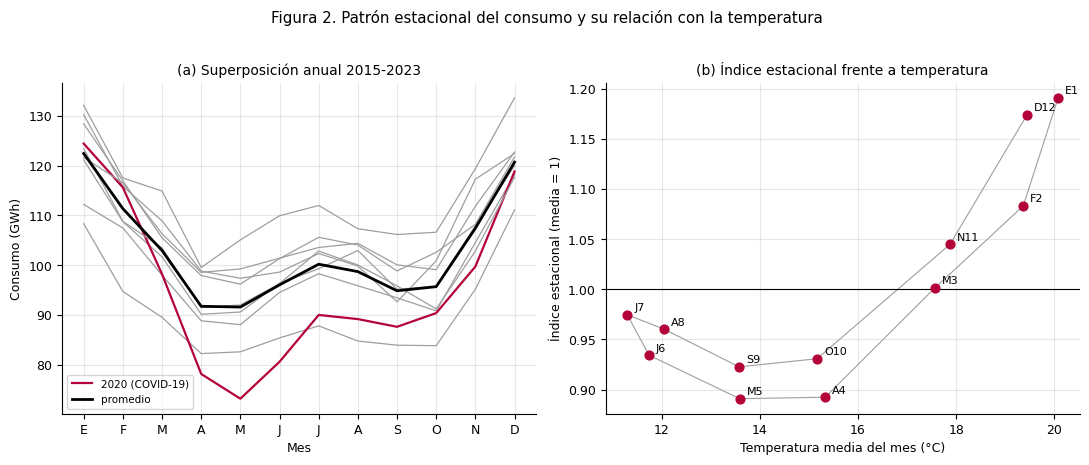

,E,F,M,A,M,J,J,A,S,O,N,D
índice estacional,1.191,1.083,1.001,0.892,0.891,0.934,0.975,0.96,0.923,0.931,1.045,1.174
temperatura (°C),20.100,19.400,17.600,15.300,13.600,11.700,11.300,12.10,13.600,15.200,17.900,19.400


Mes del máximo anual: {2015: 12, 2016: 12, 2017: 1, 2018: 1, 2019: 1, 2020: 1, 2021: 1, 2022: 12, 2023: 12}
Mes del máximo invernal: {2015: 7, 2016: 7, 2017: 8, 2018: 7, 2019: 7, 2020: 7, 2021: 7, 2022: 8, 2023: 7}


In [6]:
# --- Figura 2: patrón estacional y relación con la temperatura media ---
perfil = y.groupby(y.index.month).mean() / y.mean()      # índice estacional (media = 1)
temp_mes = train["temperatura_media_c"].groupby(train.index.month).mean()
meses = ["E", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for anio, g in y.groupby(y.index.year):                   # un trazo por año; 2020 destacado
    es2020 = anio == 2020
    axes[0].plot(g.index.month, g.values, color=ROJO if es2020 else GRIS,
                 lw=1.6 if es2020 else 0.9, label="2020 (COVID-19)" if es2020 else None)
axes[0].plot(range(1, 13), y.groupby(y.index.month).mean(), "k", lw=2, label="promedio")
axes[0].set_xticks(range(1, 13), meses)
axes[0].set(xlabel="Mes", ylabel="Consumo (GWh)", title="(a) Superposición anual 2015-2023")
axes[0].legend(fontsize=7.5)
axes[1].plot(temp_mes, perfil, "-", color=GRIS, lw=0.8)    # recorrido enero → diciembre
axes[1].scatter(temp_mes, perfil, color=ROJO, s=40, zorder=3)
for m in range(1, 13):
    axes[1].annotate(f"{meses[m - 1]}{m}", (temp_mes[m], perfil[m]),
                     textcoords="offset points", xytext=(5, 3), fontsize=8)
axes[1].axhline(1, color="k", lw=0.8)
axes[1].set(xlabel="Temperatura media del mes (°C)", ylabel="Índice estacional (media = 1)",
            title="(b) Índice estacional frente a temperatura")
fig.suptitle("Figura 2. Patrón estacional del consumo y su relación con la temperatura", y=1.02)
plt.tight_layout()
plt.show()
display(pd.DataFrame({"índice estacional": perfil.round(3), "temperatura (°C)": temp_mes.round(1)})
        .T.set_axis(meses, axis=1))
invierno = y[y.index.month.isin(range(5, 10))]             # mayo a septiembre
print("Mes del máximo anual:", y.groupby(y.index.year).idxmax().dt.month.to_dict())
print("Mes del máximo invernal:", invierno.groupby(invierno.index.year).idxmax().dt.month.to_dict())

**Estacionalidad.** Todos los años repiten la forma (Figura 2a): máximo en verano (enero o diciembre en los nueve años), mínimo en abril–mayo, **segundo máximo en invierno** (julio en siete años, agosto en dos) y segundo mínimo en septiembre–octubre. El índice va de 0,891 (mayo) a 1,191 (enero). En 2020 la forma se mantiene, desplazada hacia abajo: el shock afectó el nivel, no el calendario.

**Temperatura.** La relación tiene forma de U (Figura 2b): el consumo es mínimo con 13,6–15,3 °C y sube en ambos extremos, enero (20,1 °C) y julio (11,3 °C), compatible con climatización en verano y calefacción e iluminación en invierno; una correlación lineal subestimaría esta relación.

### 5.3 ¿La amplitud estacional crece con el nivel?

Si el esquema es multiplicativo, la amplitud absoluta acompaña al nivel y la relativa se mantiene estable.

In [7]:
# --- ¿Esquema aditivo o multiplicativo? Amplitud estacional año a año ---
anual = y.groupby(y.index.year)
amp = pd.DataFrame({"media (GWh)": anual.mean(),
                    "amplitud máx-mín (GWh)": anual.max() - anual.min(),
                    "desv. est. (GWh)": anual.std()})
amp["amplitud relativa (%)"] = 100 * amp["amplitud máx-mín (GWh)"] / amp["media (GWh)"]
display(amp.round(2).T)
n_ = amp.drop(index=[2020, 2021])                         # años sin el shock
cambio = lambda c: 100 * (n_[c].iloc[-1] / n_[c].iloc[0] - 1)
print(f"Sin 2020-2021: media {cambio('media (GWh)'):+.0f} %, amplitud absoluta "
      f"{cambio('amplitud máx-mín (GWh)'):+.0f} %, amplitud relativa "
      f"{n_['amplitud relativa (%)'].mean():.1f} % ± {n_['amplitud relativa (%)'].std():.1f}")

fecha,2015,2016,2017,2018,2019,2020,2021,2022,2023
media (GWh),90.78,99.18,102.46,107.09,107.26,95.49,102.15,107.10,113.66
amplitud máx-mín (GWh),28.84,30.11,31.01,37.59,32.18,51.21,32.19,24.16,34.05
desv. est. (GWh),9.84,9.51,10.28,11.72,10.02,16.48,10.24,8.88,10.54
amplitud relativa (%),31.77,30.36,30.26,35.10,30.00,53.63,31.51,22.56,29.96


Sin 2020-2021: media +25 %, amplitud absoluta +18 %, amplitud relativa 30.0 % ± 3.8


Sin 2020–2021, la media anual sube 25 % y la amplitud absoluta 18 % (28,84 → 34,05 GWh), mientras la relativa se mantiene en torno a 30 % (± 3,8 puntos): la evidencia favorece moderadamente un **comportamiento multiplicativo**, aunque, como el nivel varía poco, la diferencia práctica con el aditivo es acotada. La excepción es 2020 (amplitud relativa de 53,63 %), por el shock.

### 5.4 Covariables explicativas

El análisis es **univariado**; las covariables solo apoyan la interpretación de lo observado (UNAB, s. f.-a).

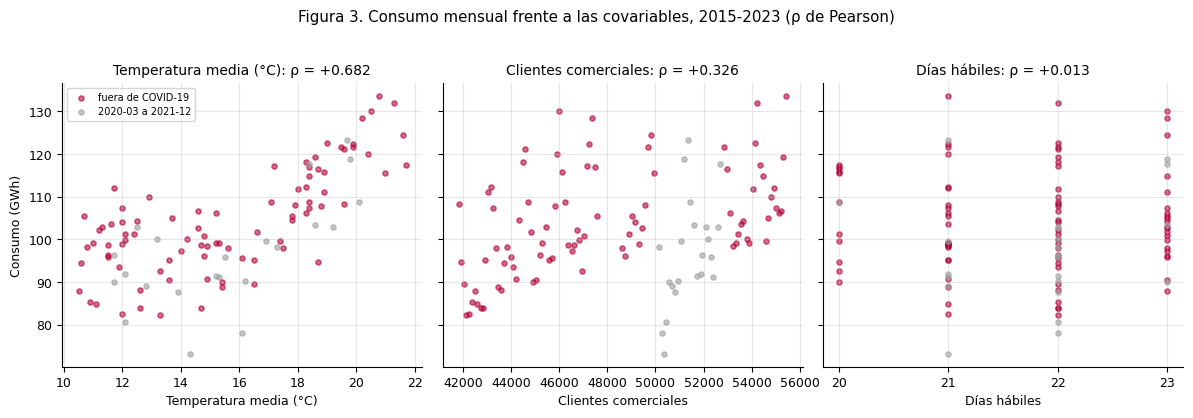

Días hábiles: ρ bruto = +0.013 | ρ entre su desviación del promedio mensual y el irregular del consumo = +0.441 (n = 74, banda aprox. ±0.228)


In [8]:
# --- Figura 3: consumo frente a las tres covariables (solo 2015-2023) ---
covars = {"temperatura_media_c": "Temperatura media (°C)", "clientes_comerciales": "Clientes comerciales",
          "dias_habiles": "Días hábiles"}
X = train[list(covars)]                                   # covariables del periodo de entrenamiento
meses_covid = pd.date_range(*covid, freq="MS")
en_covid = X.index.isin(meses_covid)
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for ax, (var, etiqueta) in zip(axes, covars.items()):
    ax.scatter(X.loc[~en_covid, var], y[~en_covid], s=14, alpha=0.6, color=ROJO, label="fuera de COVID-19")
    ax.scatter(X.loc[en_covid, var], y[en_covid], s=14, alpha=0.6, color=GRIS, label="2020-03 a 2021-12")
    ax.set(xlabel=etiqueta, title=f"{etiqueta}: ρ = {np.corrcoef(X[var], y)[0, 1]:+.3f}")
axes[0].set_ylabel("Consumo (GWh)")
axes[0].legend(fontsize=7)
axes[2].set_xticks(range(20, 24))                       # días hábiles: valores enteros
fig.suptitle("Figura 3. Consumo mensual frente a las covariables, 2015-2023 (ρ de Pearson)", y=1.03)
plt.tight_layout()
plt.show()
# --- Días hábiles: su efecto se busca en el componente irregular (sin nivel ni estacionalidad) ---
nivel_y = y.rolling(12, center=True).mean().rolling(2, center=True).mean().shift(-1)  # media móvil 2x12
razon_y = (y / nivel_y).dropna()                                                   # estacionalidad + irregular
irreg_y = razon_y / razon_y.groupby(razon_y.index.month).transform("median")        # solo irregular
irreg_y = irreg_y.drop(irreg_y.index.intersection(meses_covid))                     # sin el shock
dh_desv = X["dias_habiles"] - X["dias_habiles"].groupby(X.index.month).transform("mean")
rho_dh = np.corrcoef(dh_desv[irreg_y.index], irreg_y)[0, 1]
print(f"Días hábiles: ρ bruto = {np.corrcoef(X['dias_habiles'], y)[0, 1]:+.3f} | ρ entre su desviación "
      f"del promedio mensual y el irregular del consumo = {rho_dh:+.3f} "
      f"(n = {len(irreg_y)}, banda aprox. ±{1.96 / np.sqrt(len(irreg_y)):.3f})")

- **Temperatura (ρ = +0,682).** Refleja sobre todo el máximo de verano (relación en U, sección 5.2); comparte calendario con la estacionalidad y no puede separarse de ella con estos datos.
- **Clientes (ρ = +0,326).** Ambas series crecen en el tiempo: la correlación puede deberse a una tendencia común.
- **Días hábiles (ρ = +0,013).** Nula en la serie bruta, porque domina la estacionalidad; al comparar su desviación respecto del promedio de su mes con el irregular del consumo, la asociación es positiva y moderada (ρ = +0,441).

Estas correlaciones son descriptivas y no implican causalidad.

| Elemento | Decisión 5.4 — Enfoque |
|---|---|
| **Decisión** | Enfoque univariado; covariables como apoyo explicativo. |
| **Evidencia** | La temperatura sigue el calendario estacional; clientes se confunde con la tendencia; días hábiles solo se asocia con el irregular. |
| **Alternativa descartada** | Incorporar covariables ahora: excede el alcance exploratorio de la Semana 1. |
| **Consecuencia** | Días hábiles queda como posible variable explicativa en etapas posteriores. |

## 6. Descomposición de la serie

| Elemento | Decisión 6 — Método y esquema |
|---|---|
| **Decisión** | STL (Cleveland et al., 1990) sobre el **logaritmo** del consumo, periodo 12, `robust=True`. |
| **Evidencia** | Amplitud proporcional al nivel (sección 5.3): el logaritmo vuelve aditivo el esquema (log *y* = *T* + *S* + *R*) y el ajuste robusto evita que el shock deforme *T* y *S*. |
| **Alternativa descartada** | Descomposición clásica: promedia 2020 en los factores y pierde seis meses por extremo. |
| **Consecuencia** | Con la exponencial, la tendencia queda en GWh, la estacionalidad como factor (1,20 = +20 %) y el residuo como desviación proporcional. |

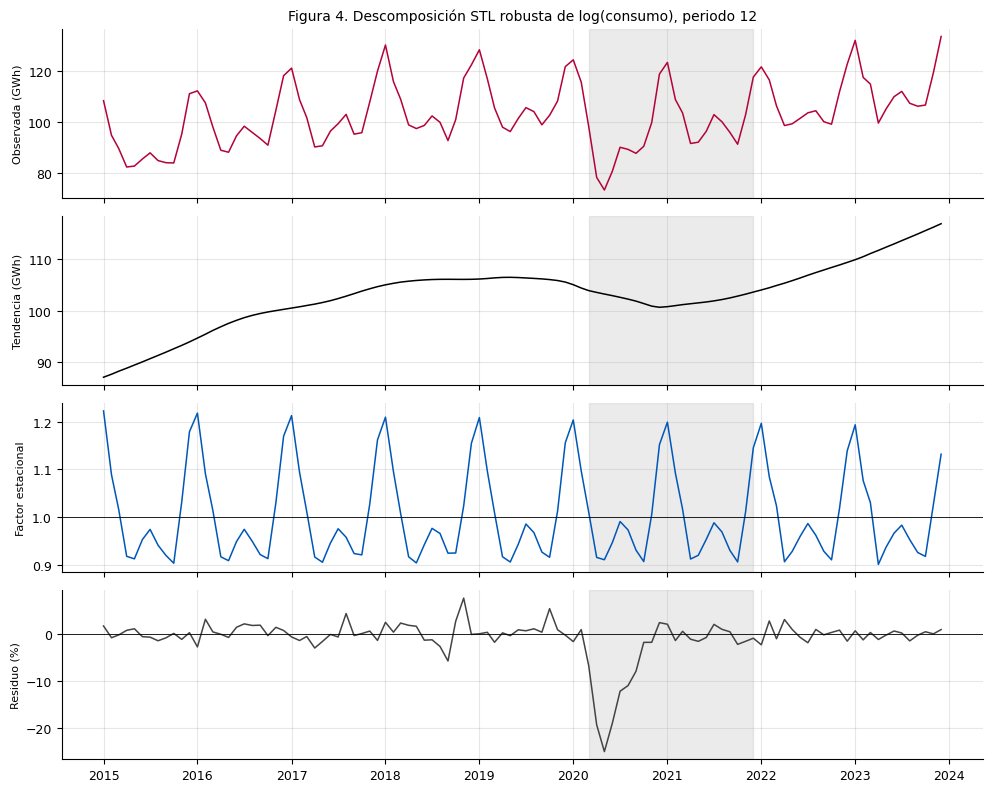

Tendencia, promedio anual (GWh): {2015: 90.4, 2016: 98.0, 2017: 102.4, 2018: 105.8, 2019: 106.2, 2020: 102.7, 2021: 102.0, 2022: 106.6, 2023: 113.3}
Tendencia: máximo previo 106.5 (2019-05) → mínimo 100.7 (2020-12), -5.5 %
Factor estacional (enero | julio | mín. abr-oct): {2015: (1.222, 0.975, 0.904), 2019: (1.209, 0.986, 0.906), 2023: (1.193, 0.984, 0.901)}
Residuo: desv. est. 4.3 % (total) | 1.8 % (sin COVID)
|Residuo| > 5 % fuera del COVID (%): {'2018-09': -5.75, '2018-11': 7.67, '2019-10': 5.42}
|Residuo| > 5 % en COVID: 7 meses (2020-03 a 2020-09), mínimo -25.09 % (2020-05), peso robusto máximo 0.00
Fuerza de la estacionalidad: 0.84 | de la tendencia: 0.67


In [9]:
# --- Descomposición STL robusta del logaritmo (esquema multiplicativo, s = 12) ---
stl = STL(np.log(y), period=12, robust=True).fit()   # robust: menor peso a extremos
tendencia = np.exp(stl.trend)                        # en GWh
factor_est = np.exp(stl.seasonal)                    # factor multiplicativo (1,20 = +20 %)
residuo = stl.resid                                  # log-residuo ≈ desviación proporcional
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
paneles = [(y, "Observada (GWh)", ROJO), (tendencia, "Tendencia (GWh)", "k"),
           (factor_est, "Factor estacional", AZUL), (100 * residuo, "Residuo (%)", "#444444")]
for ax, (serie, titulo, color) in zip(axes, paneles):
    ax.axvspan(*covid, color=GRIS, alpha=0.2)
    ax.plot(serie.index, serie, color=color, lw=1.1)
    ax.set_ylabel(titulo, fontsize=8)
axes[2].axhline(1, color="k", lw=0.6)
axes[3].axhline(0, color="k", lw=0.6)
axes[0].set_title("Figura 4. Descomposición STL robusta de log(consumo), periodo 12")
plt.tight_layout()
plt.show()
# --- Resumen numérico de los componentes ---
print("Tendencia, promedio anual (GWh):", tendencia.groupby(tendencia.index.year).mean().round(1).to_dict())
previo, covid_t = tendencia[:"2020-02"], tendencia["2020":"2021"]
print(f"Tendencia: máximo previo {previo.max():.1f} ({previo.idxmax():%Y-%m}) → mínimo {covid_t.min():.1f} "
      f"({covid_t.idxmin():%Y-%m}), {100 * (covid_t.min() / previo.max() - 1):+.1f} %")
fe = {a: factor_est[str(a)].values for a in (2015, 2019, 2023)}     # factor por mes (E..D)
print("Factor estacional (enero | julio | mín. abr-oct):",
      {a: (round(float(v[0]), 3), round(float(v[6]), 3), round(float(v[3:10].min()), 3)) for a, v in fe.items()})
sin_covid = residuo.drop(pd.date_range(*covid, freq="MS"))
print(f"Residuo: desv. est. {100 * residuo.std():.1f} % (total) | {100 * sin_covid.std():.1f} % (sin COVID)")
grandes = 100 * residuo[residuo.abs() > 0.05]                  # |residuo| > 5 %
en_cov = grandes.index.isin(pd.date_range(*covid, freq="MS"))
print("|Residuo| > 5 % fuera del COVID (%):", {f"{d:%Y-%m}": round(v, 2) for d, v in grandes[~en_cov].items()})
print(f"|Residuo| > 5 % en COVID: {en_cov.sum()} meses ({grandes[en_cov].index.min():%Y-%m} a "
      f"{grandes[en_cov].index.max():%Y-%m}), mínimo {grandes.min():.2f} % ({grandes.idxmin():%Y-%m}), "
      f"peso robusto máximo {stl.weights[grandes[en_cov].index].max():.2f}")
fuerza = lambda c: max(0, 1 - residuo.var() / (c + residuo).var())  # Hyndman y Athanasopoulos
print(f"Fuerza de la estacionalidad: {fuerza(stl.seasonal):.2f} | de la tendencia: {fuerza(stl.trend):.2f}")

**Tendencia.** Sube de 90,4 GWh (2015) a 105,8 GWh (2018), se aplana en 2019, baja hasta 100,7 GWh (diciembre de 2020) y alcanza 113,3 GWh en 2023. Por el ajuste robusto no absorbe el shock: cae 5,5 % desde su máximo previo, frente a caídas de hasta 24 % en la serie. Fuerza: 0,67 (Hyndman y Athanasopoulos, 2021).

**Estacionalidad.** Componente dominante (fuerza 0,84) que reproduce el doble máximo: en 2015, enero está 22 % sobre el nivel, julio 2,5 % bajo él y los mínimos entre 8 % y 10 % bajo él. Es estable, con leve atenuación del máximo de verano (enero: 1,222 → 1,193 entre 2015 y 2023).

**Ciclo.** Un ciclo es una oscilación de periodo variable, no ligada al calendario y de varios años (Hyndman y Athanasopoulos, 2021; UNAB, s. f.-b). En nueve años solo hay un estancamiento (2019) y una caída con causa conocida (2020): **el ciclo no es identificable** y la tendencia STL se lee como tendencia-ciclo.

**Residuo.** Desviación estándar de 4,3 % en toda la serie y de 1,8 % fuera del COVID: el error ordinario es pequeño. Concentra el shock (−25,1 % en mayo de 2020, peso robusto nulo); fuera de él solo 2018-09, 2018-11 y 2019-10 superan el 5 % y, sin causa documentada, se conservan.

## 7. Análisis de autocorrelación (ACF y PACF)

La lectura de correlogramas supone estacionariedad (Box et al., 2015; UNAB, s. f.-b), que esta serie difícilmente cumple; por eso se analizan la **serie original** y la **serie desestacionalizada** (log *y* − *S*). Se usan 36 rezagos con bandas al 95 % (Bartlett en la ACF; ±1,96/√*n* en la PACF).

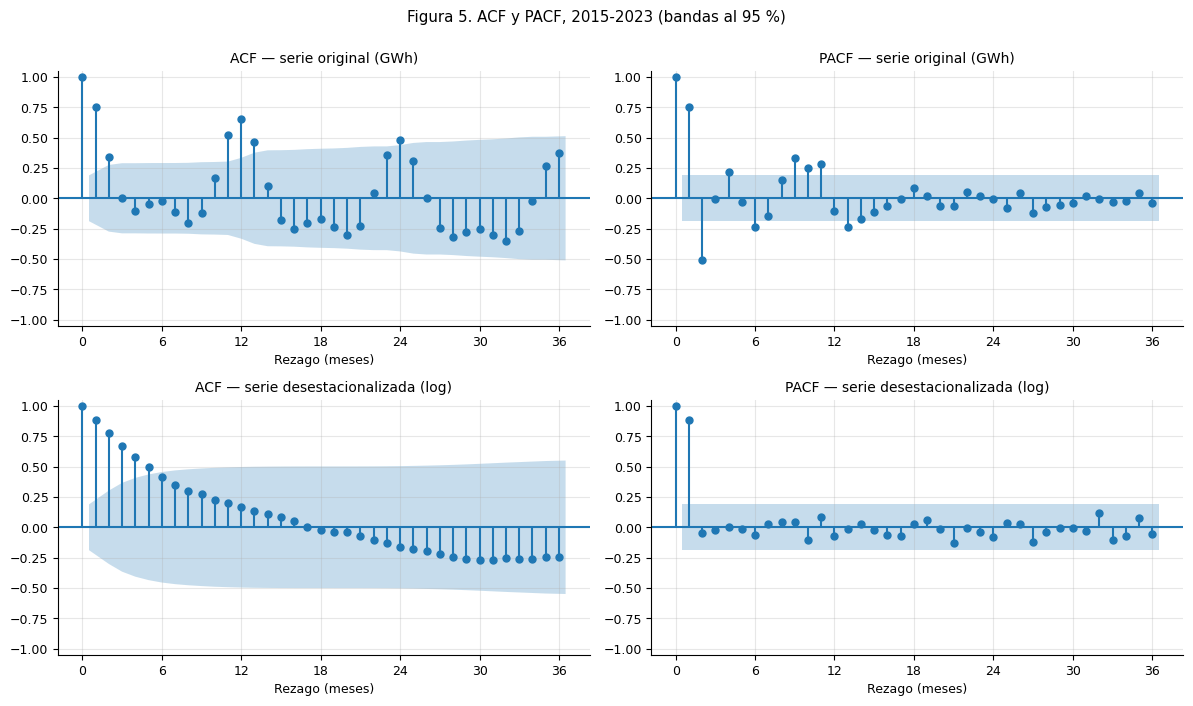

original: ACF fuera de banda {1: 0.748, 2: 0.337, 11: 0.523, 12: 0.65, 13: 0.46, 24: 0.476}
original: PACF fuera de banda (±0.189) {1: 0.748, 2: -0.507, 4: 0.22, 6: -0.236, 9: 0.333, 10: 0.252, 11: 0.285, 13: -0.233}
desestac.: ACF fuera de banda {1: 0.885, 2: 0.773, 3: 0.669, 4: 0.579, 5: 0.499}
desestac.: PACF fuera de banda (±0.189) {1: 0.885}


,1,2,3,6,11,12,13,24,36
ACF — original,0.748,0.337,-0.002,-0.021,0.523,0.650,0.460,0.476,0.376
banda — original,0.189,0.275,0.289,0.291,0.302,0.333,0.376,0.438,0.512
PACF — original,0.748,-0.507,-0.006,-0.236,0.285,-0.105,-0.233,-0.004,-0.038
ACF — desestac.,0.885,0.773,0.669,0.416,0.201,0.164,0.130,-0.164,-0.243
banda — desestac.,0.189,0.302,0.366,0.455,0.494,0.497,0.499,0.504,0.550
PACF — desestac.,0.885,-0.050,-0.026,-0.065,0.081,-0.076,-0.016,-0.079,-0.059



Residuo STL, ACF rezago 1: 0.758 (2015-2023) | 0.142 (2015-01 a 2020-02; banda ±0.249)


In [10]:
# --- Figura 5: ACF y PACF de la serie original y de la serie desestacionalizada ---
N_LAGS = 36                                         # tres años de rezagos (s = 12)
desest = np.log(y) - stl.seasonal                   # log-serie sin componente estacional
series_acf = {"serie original (GWh)": y, "serie desestacionalizada (log)": desest}
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for fila, (nombre, serie) in enumerate(series_acf.items()):
    plot_acf(serie, lags=N_LAGS, alpha=0.05, ax=axes[fila, 0], title=f"ACF — {nombre}")
    plot_pacf(serie, lags=N_LAGS, alpha=0.05, method="ywm", ax=axes[fila, 1],
              title=f"PACF — {nombre}")
    for ax in axes[fila]:
        ax.set_xticks(range(0, N_LAGS + 1, 6))
        ax.set_ylim(-1.05, 1.05)
        ax.set_xlabel("Rezago (meses)")
fig.suptitle("Figura 5. ACF y PACF, 2015-2023 (bandas al 95 %)", y=1.0)
plt.tight_layout()
plt.show()
# --- Valores y rezagos fuera de las MISMAS bandas que dibujan los gráficos ---
# ACF: banda de Bartlett 1,96·√[(1 + 2·Σ_{j<k} r_j²)/n], que crece con el rezago (plot_acf).
# PACF: banda ±1,96/√n (plot_pacf).
n = len(y)
rez = [1, 2, 3, 6, 11, 12, 13, 24, 36]
b_p = 1.96 / np.sqrt(n)
filas = {}
for nombre, serie in series_acf.items():
    corto = "original" if "original" in nombre else "desestac."  # etiqueta corta de fila
    r = acf(serie, nlags=N_LAGS)
    p = pacf(serie, nlags=N_LAGS, method="ywm")
    banda = 1.96 * np.sqrt(np.r_[np.nan, 1 + 2 * np.cumsum(np.r_[0, r[1:N_LAGS] ** 2])] / n)
    filas.update({f"ACF — {corto}": r[rez], f"banda — {corto}": banda[rez],
                  f"PACF — {corto}": p[rez]})
    print(f"{corto}: ACF fuera de banda", {k: round(float(r[k]), 3) for k in range(1, N_LAGS + 1)
                                          if abs(r[k]) > banda[k]})
    print(f"{corto}: PACF fuera de banda (±{b_p:.3f})",
          {k: round(float(p[k]), 3) for k in range(1, N_LAGS + 1) if abs(p[k]) > b_p})
display(pd.DataFrame(filas, index=rez).round(3).T)
# Dependencia que queda en el residuo STL, con y sin el episodio COVID
pre = residuo[:"2020-02"]
print(f"\nResiduo STL, ACF rezago 1: {acf(residuo, nlags=1)[1]:.3f} (2015-2023) | "
      f"{acf(pre, nlags=1)[1]:.3f} (2015-01 a 2020-02; banda ±{1.96 / np.sqrt(len(pre)):.3f})")

**Persistencia.** La ACF es alta en el rezago 1 (0,748), significativa en el 2 (0,337) y decae con rapidez antes de que reaparezca la estructura estacional en torno al rezago 12.

**Estacionalidad.** Picos significativos en 11, 12 y 13 (0,523; 0,650; 0,460) y en 24 (0,476 > banda 0,438); el 36 (0,376) queda dentro de su banda (0,512). El lento decaimiento de los picos indica estacionalidad persistente. El rezago 6 presenta una autocorrelación prácticamente nula (−0,021), por lo que no existe evidencia de una dependencia semestral marcada. La estructura dominante es anual, como muestran los picos significativos en los rezagos 12 y 24. El segundo máximo anual se observa principalmente en el perfil estacional de la Figura 2.

**PACF.** La PACF presenta efectos significativos en los primeros rezagos, especialmente en 1 (0,748) y 2 (−0,507), lo que evidencia dependencia temporal de corto plazo. Los demás picos significativos (4, 6, 9, 10, 11 y 13; |valor| entre 0,22 y 0,33) deben interpretarse con cautela porque la serie conserva tendencia y estacionalidad.

**Dependencia del nivel.** Sin estacionalidad, la ACF decae lenta y casi linealmente (0,885; 0,773; 0,669; significativa hasta el rezago 5) y la PACF solo destaca en el rezago 1: **comportamiento compatible con no estacionariedad en nivel** (tendencia y shock). La autocorrelación del residuo STL se concentra en el COVID: ACF(1) de 0,758 en toda la muestra y de 0,142 antes del shock (banda ±0,249).

## 8. Interpretación técnica integrada

Exploración (Figuras 1–3), descomposición (Figura 4) y correlogramas (Figura 5) describen la misma estructura: estacionalidad anual estable y dominante (ACF significativa en los rezagos 12 y 24), con doble máximo (Figura 2) y amplitud proporcional al nivel; tendencia no lineal cuya persistencia aparece al desestacionalizar; un shock temporal que concentra el residuo y su autocorrelación; y error ordinario pequeño, sin ciclo identificable. Las covariables son coherentes con esta lectura, sin probar causalidad, y la PACF muestra dependencia de corto plazo en los rezagos 1 y 2.

| Hallazgo (evidencia) | Implicancia para el modelamiento posterior |
|---|---|
| Estacionalidad persistente, *s* = 12 (ACF 12 y 24; fuerza 0,84) | El modelo deberá incorporar explícitamente la estacionalidad anual. |
| Persistencia del nivel (ACF desestacionalizada hasta el rezago 5) | Deberá evaluarse si la serie requiere transformaciones para ser estacionaria. |
| Amplitud proporcional al nivel (sección 5.3) | Evaluar el uso del logaritmo del consumo. |
| Shock 2020-03 a 2021-12 (residuo hasta −25 %) | Definir un tratamiento explícito del episodio. |

## 9. Conclusiones

Con 108 meses de entrenamiento (2015–2023), el consumo comercial de DEL combina una **estacionalidad anual aproximadamente multiplicativa, con doble máximo**, estable y compatible con los extremos de temperatura; una **tendencia creciente no lineal**; y un **shock temporal** por COVID-19 (marzo de 2020 a diciembre de 2021). No se identifica ciclo y el error ordinario es pequeño. Estos patrones deberán considerarse en las etapas posteriores de modelamiento.

## 10. Limitaciones

Nueve años de datos permiten caracterizar la estacionalidad anual, pero son limitados para identificar ciclos de largo plazo. La validación de la imputación usa 5 o 6 meses por hueco. La ventana COVID y la robustez de STL condicionan la separación entre tendencia y residuo. Las bandas de ACF y PACF suponen ruido blanco, y las correlaciones con covariables son descriptivas.

## 11. Referencias

Box, G. E. P., Jenkins, G. M., Reinsel, G. C., y Ljung, G. M. (2015). *Time series analysis: Forecasting and control* (5.ª ed.). Wiley.

Cleveland, R. B., Cleveland, W. S., McRae, J. E., y Terpenning, I. (1990). STL: A seasonal-trend decomposition procedure based on loess. *Journal of Official Statistics*, *6*(1), 3–73.

Hyndman, R. J., y Athanasopoulos, G. (2021). *Forecasting: Principles and practice* (3.ª ed.). OTexts. https://otexts.com/fpp3/

Seabold, S., y Perktold, J. (2010). Statsmodels: Econometric and statistical modeling with Python. En S. van der Walt y J. Millman (Eds.), *Proceedings of the 9th Python in Science Conference* (pp. 92–96). https://doi.org/10.25080/Majora-92bf1922-011

Universidad Andrés Bello. (s. f.-a). *MCDI505 — Análisis de series de tiempo. Caso transversal del curso: Documento base* [Notebook de Jupyter]. Material docente del curso, Magíster en Ciencia de Datos.

Universidad Andrés Bello. (s. f.-b). *MCDI505 — Sesión 1: Naturaleza de los datos temporales y autocorrelación* [Notebook de Jupyter]. Material docente del curso, Magíster en Ciencia de Datos.


---
**Declaración de uso de IA.** Se utilizó un asistente de IA generativa como apoyo para organizar ideas y mejorar la redacción del informe. Los análisis, resultados, decisiones metodológicas e interpretaciones fueron revisados y validados personalmente mediante la ejecución del notebook y el material de la asignatura.
